<a href="https://colab.research.google.com/github/Rio-HEPLab/ML4Physics/blob/PPGF-2025-1/save/Solved_Exer_DTrees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Soluções Exercícios (livro, capítulo 6):

7. Treine e ajuste a `Decision Tree` do conjunto de dados de "luas" (*moon's dataset*).

   1. Gere o conjunto de dados de "luas" usando `make_moons(n_samples=10000, noise=0.4)`;

In [ ]:
# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

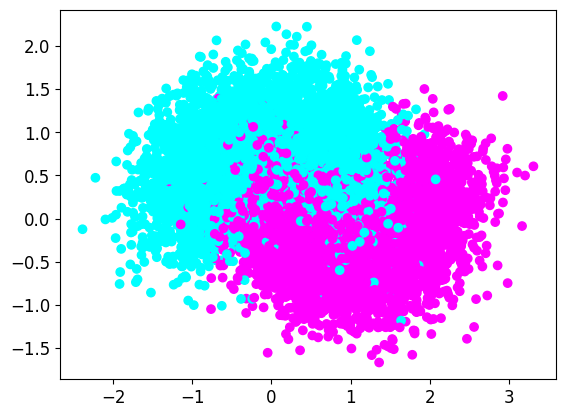

In [ ]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=10000, noise=0.4, random_state=42)
plt.scatter(X[:,0],X[:,1],c=y,cmap="cool")

2. Divida-o em um conjunto de treino e um de teste, usando a função `train_test_split()`;
   
   

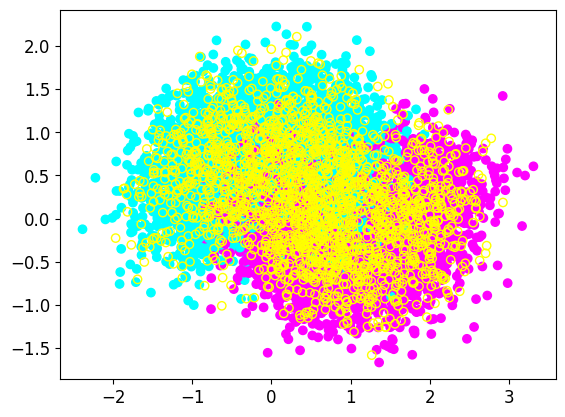

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.scatter(X_train[:,0],X_train[:,1],c=y_train,cmap="cool")
#em amarelo mostramos os dados de teste, que nosso algoritmo devera classificar
plt.scatter(X_test[:,0],X_test[:,1],color="yellow",facecolor="none")

 3. Use o método de busca com validação cruzada (*grid search with cross-validation*), com a ajuda da classe `GridSearchCV` para encontrar bons valores de hyperparâmetros para um `DecisionTreeClassifier`. Dica: tente diferentes valores para `max_leaf_nodes`;

 **Cross-validation:**


 Quando precisamos testar vários conjuntos de hyperparâmetros para determinar o melhor modelo, se testarmos todos os conjuntos no mesmo conjunto de teste, podemos estar introduzindo um ***bias***. Para evitar isso, podemos sub-dividir nossa amostra de teste em duas amostras:
 * validação (escolha do modelo apropriado)
 * teste (aplicação do melhor modelo)



Para não "gastarmos" dados de treinamento em conjuntos de validação, uma técnica comum é:
* **dividir** a amostra de treinamento em diferentes subconjuntos;
* **treinar** cada modelo (combinações de hyperparâmetros) em uma **combinação** diferente dessas sub-amostras;
* **validar** cada modelo nas sub-amostras restantes;
* Uma vez que o modelo foi determinado, **testar** na amostra de teste.



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier


params = {'max_leaf_nodes': list(range(2, 100)), 'min_samples_split': [2, 3, 4]}
grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1, verbose=1, cv=3)

grid_search_cv.fit(X_train, y_train)

Fitting 3 folds for each of 294 candidates, totalling 882 fits


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                            13, 14, 15, 16, 17, 18, 19, 20, 21,
                                            22, 23, 24, 25, 26, 27, 28, 29, 30,
                                            31, ...],
                         'min_samples_split': [2, 3, 4]},
             verbose=1)

In [ ]:
grid_search_cv.best_estimator_

DecisionTreeClassifier(max_leaf_nodes=17, random_state=42)

4. Treine o estimador no conjunto de dados completo usando esses hyperparâmetros e meça o desempenho do seu modelo no conjunto de dados de teste. Você deve obter uma acurácia de aproximadamente 85% a 87%.

==> **Por default**, o `GridSearchCV` já treina o melhor modelo encontrado no conjunto completo de treinamento (`refit=True`).

Podemos calcular a acurácia diretamente:   
   


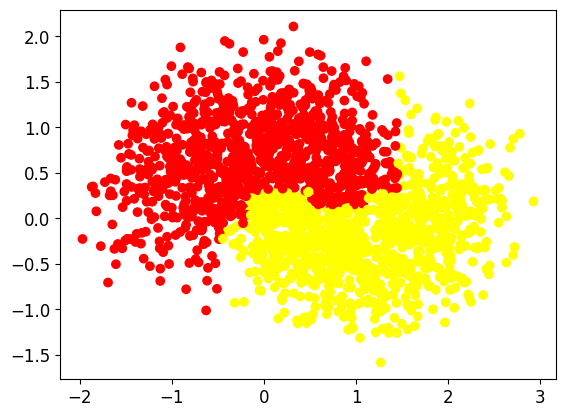

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = grid_search_cv.predict(X_test)
accuracy_score(y_test, y_pred)

plt.scatter(X_test[:,0],X_test[:,1],c=y_pred,cmap="autumn")

8. **Faça crescer uma floresta.**

   1. Continuando do exercício anterior, gere 1000 sub-conjuntos do conjunto de treinamento, cada sub-conjunto contendo 100 instâncias selecionadas aleatoriamente. Dica: você pode usar a classe do scikit-learn, `ShuffleSplit`;
   
   

In [ ]:
print(len(X_train))

8000


In [ ]:
from sklearn.model_selection import ShuffleSplit
"""
Geração de n_trees (1000) trees a serem treinadas em conjuntos de
n_instances dados.
Para cada tree, a função rs.split() faz uma rearrumação dos índices de uma sub-amostra de teste
e com isso produz uma mini-amostra de treinamento, com "n_instances" cada.
Nesse exemplo abaixo, geramos "n_trees" amostras com "n_instances" dados cada.

"""
n_trees = 1000
n_instances = 100

mini_sets = []
mini_sets2=[]

rs = ShuffleSplit(n_splits=n_trees, test_size=len(X_train) - n_instances, random_state=42)
#USAR O PARAMETRO train_size TAMBEM SERVE E DA O RESULTADO IDENTICO

rs2 = ShuffleSplit(n_splits=n_trees, train_size=n_instances,random_state=42) #tambem serve

for mini_train_index, mini_test_index in rs.split(X_train):
    #print("TRAIN size:", len(mini_train_index), "TEST size:", len(mini_test_index) )
    X_mini_train = X_train[mini_train_index]
    y_mini_train = y_train[mini_train_index]
    mini_sets.append((X_mini_train, y_mini_train))

for mini_train_index, mini_test_index in rs2.split(X_train):
    #print("TRAIN size:", len(mini_train_index), "TEST size:", len(mini_test_index) )
    X_mini_train2 = X_train[mini_train_index]
    y_mini_train2 = y_train[mini_train_index]
    mini_sets2.append((X_mini_train2, y_mini_train2))
# As "n_trees" amostras de treinamento estão em "mini_sets".
print(len(mini_sets))
print(len(mini_sets2))
print(mini_sets[0][0][0],mini_sets2[0][0][0])
#são identicos

1000
1000
[-0.31532549  0.49432266] [-0.31532549  0.49432266]


2. Treine uma `Decision Tree` em cada sub-conjunto, usando os melhores valores de hyperparâmetro encontrados no exercício anterior. Estime o desempenho desses 1000 conjuntos de treinamento no conjunto de teste (como eles foram treinados em um número menor de amostras, a performance será um pouco pior do que a encontrada no exercício anterior, com uma acurácia em torno de 80%);
   
   

In [ ]:
from sklearn.base import clone

# copiando a melhor configuração da tree para todas as "n_trees" trees.
forest = [clone(grid_search_cv.best_estimator_) for _ in range(n_trees)]

accuracy_scores = []
for tree, (X_mini_train, y_mini_train) in zip(forest, mini_sets):
    # para cada conjunto de treinamento (mini_train), treinamos as nossas trees
    tree.fit(X_mini_train, y_mini_train)
    # fazemos a predição no conjunto de teste
    y_pred = tree.predict(X_test)
    # e calculamos a acurácia de cada predição
    accuracy_scores.append(accuracy_score(y_test, y_pred))
# média das acurácias
np.mean(accuracy_scores)



np.float64(0.805471)

In [ ]:
#o máximo e mínimo de acurácia entre os trees
print(np.max(accuracy_scores),np.min(accuracy_scores))

0.8615 0.715


3. Para cada instância do conjunto de teste, gere as predições das 1000 `Decision Trees` e só guarde as predições mais frequentes (você pode usar a função `mode()` do  SciPy). Isso fornece o que é conhecido como *majority vote predictions* do conjunto de teste;
   
   

In [ ]:
from scipy.stats import mode

##dou de input a amostra de teste e a "floresta" já treinada

def MyClassifierRandomForest(X_test,forest):
    n_trees = len(forest)
    Y_pred = np.empty([n_trees, len(X_test)], dtype=np.uint8)
    for tree_index, tree in enumerate(forest):
        Y_pred[tree_index] = tree.predict(X_test)

    y_pred_majority_votes, n_votes = mode(Y_pred, axis=0)
    n_voted = n_votes.reshape([-1])
    y_pred_voted = y_pred_majority_votes.reshape([-1])
    return n_voted,y_pred_voted,Y_pred

4. Estime as predições no conjunto de teste: a acurácia deve ser um pouco maior que a do item anterior (da ordem de 0.5 a 1.5%). **Parabéns!** Você treinou um classificador `Random Forest`! :-)

In [ ]:
from scipy.stats import mode



n_voted,y_pred_voted,Y_pred = MyClassifierRandomForest(X_test,forest )
print("acurácia: ", accuracy_score(y_test, y_pred_voted))




acurácia:  0.872


256
0.872
Posição no plano (x1,x2) do experimento classificado errado: [-0.21010981  0.51683844]


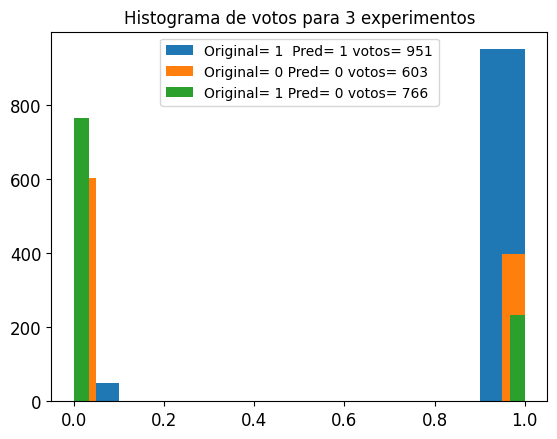

In [ ]:
#Os 3 histogramas a continuação mostram a proporção de "votos" para as instancias/experimentos [0], [-1] (o ultimo), o o decimo da lista dos "errados"


plt.hist(Y_pred[:,0],bins=10,label="Original= {:}  Pred= {:} votos= {:d}".format(y_test[0],y_pred_voted[0],int(n_voted[0])))

plt.hist(Y_pred[:,-1],bins=20,label="Original= {:} Pred= {:} votos= {:d}".format(y_test[-1],y_pred_voted[-1],int(n_voted[-1])))

w=np.where(y_test!=y_pred_voted) #selecionar as instancias onde o random forest escolheu errado
print(len(w[0]))
print(1-len(w[0])/len(y_test)) # checar que é o mesmo valor que o accuracy_score
ind10 = w[0][10]
plt.hist(Y_pred[:,ind10],bins=30,label="Original= {:} Pred= {:} votos= {:d}".format(y_test[ind10],y_pred_voted[w[0][10]],int(n_voted[ind10])))

plt.title("Histograma de votos para 3 experimentos")
plt.legend(loc="upper center")

print("Posição no plano (x1,x2) do experimento classificado errado:",X_test[ind10])


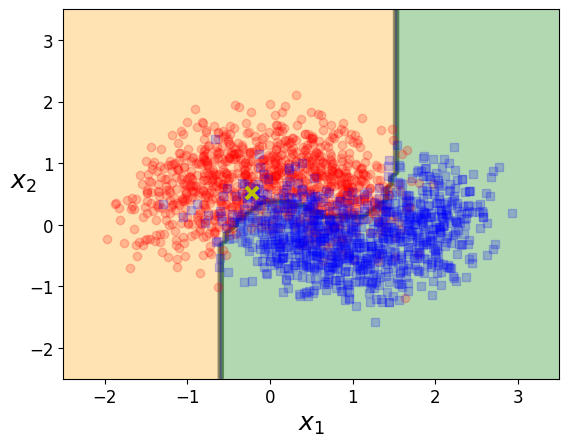

In [ ]:
from matplotlib.colors import ListedColormap

def plot_decision_RandomForest(clf, X, y, axes=[-2.5, 3.5, -2.5, 3.5], alpha=0.5, contour=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred =  clf(X_new,forest)[1].reshape(x1.shape)
    custom_cmap = ListedColormap(['orange','black','green'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if contour:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.7)
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "ro", alpha=0.2)
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", alpha=0.2)
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)
    return plt

plot_decision_RandomForest(MyClassifierRandomForest,X_test,y_test)

##o X amarelo mostra o ponto que foi classificado como "0"  mas na verdade era "1"
plt.plot(X_test[ind10,0],X_test[ind10,1],"yx",markersize=8,mew=3)